# Tesla vs Apple: Risk and Return Analysis

## 1. Problem Definition
This project compares **Tesla (TSLA)** and **Apple (AAPL)** using recent stock price data from Alpha Vantage.  
The aim is to evaluate which stock delivered **higher return**, which stock showed **higher risk**, and which stock offered **better risk-adjusted performance** over the selected period.

## 2. Target User
This analysis is designed for **retail investors** and **finance students** who want a simple Python-based comparison of two well-known stocks.

### 3. Metrics Used
This project evaluates stock performance using four key financial metrics:

1. **Cumulative Return** – measures the overall percentage gain or loss over the selected period, indicating total investment performance.

2. **Annualized Volatility** – captures the degree of price fluctuation and serves as a proxy for investment risk.

3. **Sharpe Ratio** – evaluates risk-adjusted return by measuring how much return is earned per unit of risk.

4. **Rolling Volatility** – shows how risk evolves over time, providing insights into whether a stock's volatility is stable or changing.

### 4. Data Source
The stock data were originally obtained from the Alpha Vantage API.

Due to the limitations of the free API (which provides only recent observations), the data were retrieved in advance and stored as a CSV file for reproducibility.

The analysis in this notebook is based on the saved dataset.

Access date: April 14, 2026

## 5. Package Requirements
This notebook uses pandas, numpy, and matplotlib for data analysis and visualisation.

In [1]:
# Optional: run only if needed
# !pip install pandas matplotlib numpy

## 6. Import Libraries and Load Data

This section imports the libraries required for data loading, cleaning, numerical calculation, and visualisation.

The stock data were originally obtained from the Alpha Vantage API and stored as a CSV file.  
For reproducibility, this notebook reads the saved dataset directly instead of calling the API.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings("ignore")

data = pd.read_csv("TSLA_AAPL_data.csv", index_col=0, parse_dates=True)
data = data.sort_index()

print(data.head())
print(data.info())
print(data.isna().sum())

              TSLA    AAPL
date                      
2025-11-17  408.92  267.46
2025-11-18  401.25  267.44
2025-11-19  403.99  268.56
2025-11-20  395.23  266.25
2025-11-21  391.09  271.49
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 100 entries, 2025-11-17 to 2026-04-13
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   TSLA    100 non-null    float64
 1   AAPL    100 non-null    float64
dtypes: float64(2)
memory usage: 2.3 KB
None
TSLA    0
AAPL    0
dtype: int64


## 7. Data Preview

This section displays the first few rows of the cleaned stock dataset.

The data include daily closing prices for Tesla (TSLA) and Apple (AAPL), which will be used for calculating returns, volatility, and other financial metrics.

Each row represents one trading day, and the dataset has already been prepared for analysis.

In [7]:
data.head()

,TSLA,AAPL
date,,
2025-11-17,408.92,267.46
2025-11-18,401.25,267.44
2025-11-19,403.99,268.56
2025-11-20,395.23,266.25
2025-11-21,391.09,271.49


### Brief Interpretation

The table above shows the cleaned daily closing prices for both Tesla and Apple.

Each row represents one trading day. These prices will be used to calculate daily returns and assess the performance and risk of each stock.

From this dataset, further analysis such as return, volatility, and risk-adjusted performance can be conducted.

## 8. Calculate Daily Returns
Daily return measures the percentage change in price from one day to the next.

Formula:
\[
\text{Daily Return} = \frac{P_t - P_{t-1}}{P_{t-1}}
\]

This step is necessary because volatility and Sharpe ratio are based on returns rather than raw prices.

In [8]:
# Calculate percentage daily returns for both stocks
daily_returns = data.pct_change().dropna()

# Preview the daily return data
daily_returns.head()

,TSLA,AAPL
date,,
2025-11-18,-0.018757,-0.000075
2025-11-19,0.006829,0.004188
2025-11-20,-0.021684,-0.008601
2025-11-21,-0.010475,0.019681
2025-11-24,0.068245,0.016317


## 9. Calculate Key Metrics
This section calculates the three main summary metrics used in the project.

### (1) Cumulative Return
This shows the overall return during the selected period.

### (2) Annualized Volatility
This measures the standard deviation of daily returns and converts it to an annual basis using 252 trading days.

### (3) Sharpe Ratio
This compares return with risk.  
A higher Sharpe ratio generally indicates better risk-adjusted performance.

In [9]:
def calculate_metrics(data):
    """
    Calculate cumulative return, annualized volatility, and Sharpe ratio
    for Tesla and Apple.
    """
    # Total return over the whole period
    cumulative_returns = (data.iloc[-1] - data.iloc[0]) / data.iloc[0] * 100

    # Daily percentage returns
    daily_returns = data.pct_change().dropna()

    # Annualized volatility:
    # standard deviation of daily returns × sqrt(252 trading days)
    volatility = daily_returns.std() * np.sqrt(252) * 100

    # Sharpe ratio:
    # (average daily return - daily risk-free rate) / std of daily returns
    risk_free_rate = 0.02
    excess_daily_returns = daily_returns - (risk_free_rate / 252)
    sharpe_ratio = excess_daily_returns.mean() / excess_daily_returns.std() * np.sqrt(252)

    return cumulative_returns, volatility, sharpe_ratio

cumulative_returns, volatility, sharpe_ratio = calculate_metrics(data)

# Combine the three metrics into one summary table
summary_table = pd.DataFrame({
    'Cumulative Return (%)': cumulative_returns,
    'Annualized Volatility (%)': volatility,
    'Sharpe Ratio': sharpe_ratio
})

summary_table

,Cumulative Return (%),Annualized Volatility (%),Sharpe Ratio
TSLA,-13.816883,37.397013,-0.879961
AAPL,-3.088312,21.541965,-0.356601


### Brief interpretation
When reading the summary table:

- **Higher cumulative return** means the stock gained more over the period.
- **Higher volatility** means the stock was riskier and less stable.
- **Higher Sharpe ratio** means the stock delivered better return relative to its risk.

This gives a more balanced view than looking at return alone.

## 10. Print a Simple Text Report
The following function prints a clear report that can also help when preparing your demo video script.

In [10]:
def print_report(data, cumulative_returns, volatility, sharpe_ratio):
    """Print a summary report of the main findings."""
    start_date = data.index[0].strftime('%Y-%m-%d')
    end_date = data.index[-1].strftime('%Y-%m-%d')

    print("=" * 60)
    print("Tesla (TSLA) vs Apple (AAPL): Risk and Return Comparison")
    print("=" * 60)
    print(f"Analysis period: {start_date} to {end_date}")
    print(f"Trading days: {len(data)}")

    print("\n1. Cumulative Return")
    print(f"   Tesla: {cumulative_returns['TSLA']:.2f}%")
    print(f"   Apple: {cumulative_returns['AAPL']:.2f}%")

    print("\n2. Annualized Volatility")
    print(f"   Tesla: {volatility['TSLA']:.2f}%")
    print(f"   Apple: {volatility['AAPL']:.2f}%")

    print("\n3. Sharpe Ratio")
    print(f"   Tesla: {sharpe_ratio['TSLA']:.3f}")
    print(f"   Apple: {sharpe_ratio['AAPL']:.3f}")

    print("\nInterpretation:")
    print("- Higher return is better.")
    print("- Lower volatility means lower risk.")
    print("- Higher Sharpe ratio means better risk-adjusted performance.")

print_report(data, cumulative_returns, volatility, sharpe_ratio)

Tesla (TSLA) vs Apple (AAPL): Risk and Return Comparison
Analysis period: 2025-11-17 to 2026-04-13
Trading days: 100

1. Cumulative Return
   Tesla: -13.82%
   Apple: -3.09%

2. Annualized Volatility
   Tesla: 37.40%
   Apple: 21.54%

3. Sharpe Ratio
   Tesla: -0.880
   Apple: -0.357

Interpretation:
- Higher return is better.
- Lower volatility means lower risk.
- Higher Sharpe ratio means better risk-adjusted performance.


## 11. Visualisation 1: Stock Price Comparison
This chart compares the daily closing prices of Tesla and Apple over time.

**Purpose of this chart:**  
It helps us see the general price trend and whether one stock experienced larger visible swings than the other.

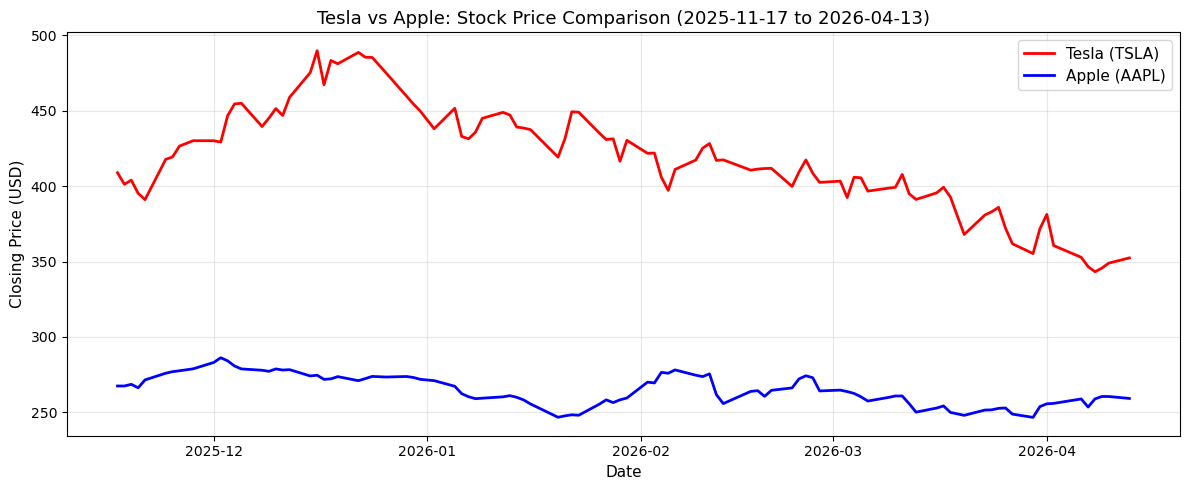

In [11]:
def plot_price_comparison(data):
    """Plot the daily closing prices of Tesla and Apple."""
    start_date = data.index[0].strftime('%Y-%m-%d')
    end_date = data.index[-1].strftime('%Y-%m-%d')

    plt.figure(figsize=(12, 5))
    plt.plot(data.index, data['TSLA'], label='Tesla (TSLA)', linewidth=2, color='red')
    plt.plot(data.index, data['AAPL'], label='Apple (AAPL)', linewidth=2, color='blue')
    plt.title(f'Tesla vs Apple: Stock Price Comparison ({start_date} to {end_date})', fontsize=13)
    plt.xlabel('Date', fontsize=11)
    plt.ylabel('Closing Price (USD)', fontsize=11)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_price_comparison(data)

### Brief interpretation
From this chart, we can visually compare the overall movement of Tesla and Apple prices.  
However, stock prices alone are not enough to judge investment attractiveness, because a higher price does not necessarily mean better performance.  
This is why return and risk metrics are calculated separately.

## 12. Visualisation 2: Rolling Volatility
Average volatility gives only one summary number.  
Rolling volatility is useful because it shows how risk changes over time.

In this project, a **20-day rolling window** is used, which is roughly equal to one trading month.

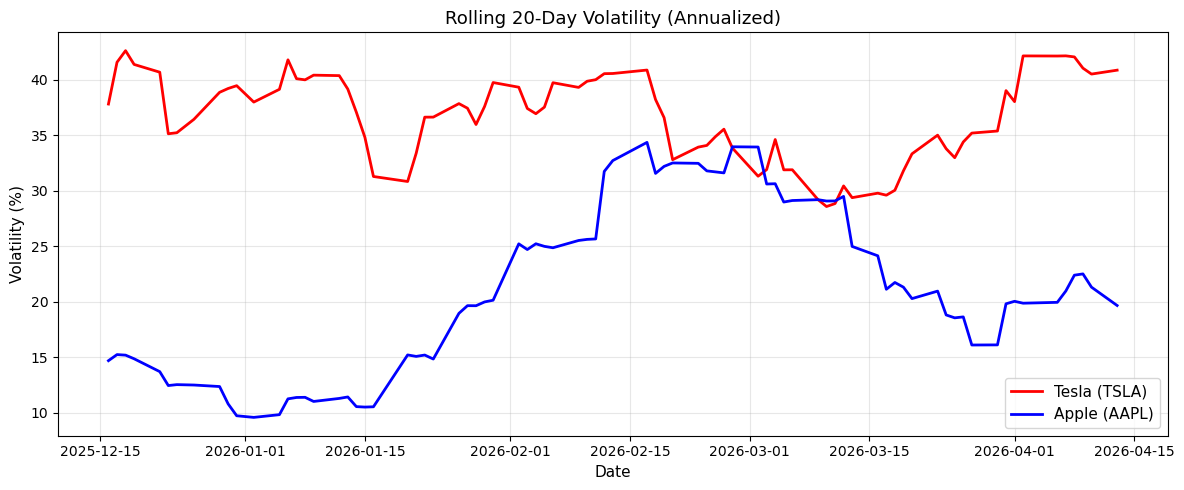

In [12]:
def plot_rolling_volatility(data, window=20):
    """Plot rolling annualized volatility for both stocks."""
    # Daily returns
    daily_returns = data.pct_change().dropna()

    # Rolling annualized volatility
    rolling_vol = daily_returns.rolling(window).std() * np.sqrt(252) * 100

    plt.figure(figsize=(12, 5))
    plt.plot(rolling_vol.index, rolling_vol['TSLA'], label='Tesla (TSLA)', linewidth=2, color='red')
    plt.plot(rolling_vol.index, rolling_vol['AAPL'], label='Apple (AAPL)', linewidth=2, color='blue')
    plt.title(f'Rolling {window}-Day Volatility (Annualized)', fontsize=13)
    plt.xlabel('Date', fontsize=11)
    plt.ylabel('Volatility (%)', fontsize=11)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_rolling_volatility(data, window=20)

### Brief Interpretation

From the chart, Tesla’s rolling volatility is consistently higher than Apple’s for most of the period.

This indicates that Tesla experienced greater short-term fluctuations and higher risk compared to Apple.

Apple’s volatility shows a more moderate pattern, although it increases temporarily during certain periods, suggesting occasional rises in market uncertainty.

Overall, Tesla appears to be the more volatile and riskier stock, while Apple demonstrates relatively more stable risk behaviour over time.

## 13. Final Conclusion
This section turns the numerical results into a simple investment interpretation.

In [13]:
def print_conclusion(cumulative_returns, volatility, sharpe_ratio):
    """Print a simple final conclusion."""
    print("=" * 60)
    print("Conclusion")
    print("=" * 60)

    if cumulative_returns['TSLA'] > cumulative_returns['AAPL']:
        print("Tesla generated the higher cumulative return during the selected period.")
    else:
        print("Apple generated the higher cumulative return during the selected period.")

    if volatility['TSLA'] > volatility['AAPL']:
        print("Tesla also showed higher volatility, meaning it carried higher risk.")
        print("Apple was relatively more stable over the same period.")
    else:
        print("Apple showed higher volatility, meaning it carried higher risk.")

    if sharpe_ratio['TSLA'] > sharpe_ratio['AAPL']:
        print("Tesla achieved the better Sharpe ratio, so its risk-adjusted performance was stronger.")
    else:
        print("Apple achieved the better Sharpe ratio, so its risk-adjusted performance was stronger.")

    print("\nOverall, the choice between the two stocks depends on investor preference:")
    print("- A risk-seeking investor may prefer the stock with stronger return potential.")
    print("- A more conservative investor may prefer the stock with lower volatility and greater stability.")
    print("\nThis project is for educational purposes only and does not constitute investment advice.")

print_conclusion(cumulative_returns, volatility, sharpe_ratio)

Conclusion
Apple generated the higher cumulative return during the selected period.
Tesla also showed higher volatility, meaning it carried higher risk.
Apple was relatively more stable over the same period.
Apple achieved the better Sharpe ratio, so its risk-adjusted performance was stronger.

Overall, the choice between the two stocks depends on investor preference:
- A risk-seeking investor may prefer the stock with stronger return potential.
- A more conservative investor may prefer the stock with lower volatility and greater stability.

This project is for educational purposes only and does not constitute investment advice.


## 14. Data Reproducibility

The dataset used in this project was originally obtained from the Alpha Vantage API and saved as a CSV file.

This ensures that the analysis can be reproduced without requiring additional data downloads.

## 15. Limitations
This project has several limitations:

- It uses only a recent period of historical price data.
- It compares only two companies.
- It does not include dividends, macroeconomic events, interest rate changes, or company news.
- The Sharpe ratio uses a simplified fixed risk-free rate assumption.

In future work, the analysis could be extended with a longer time period, more companies, or additional indicators.